<a href="https://colab.research.google.com/github/siddhartha-sai-17/Celebal-Excellence-Internship-/blob/main/week6%3CB_Sai_Siddhartha%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Assignment: Autoencoder for Image Denoising (MNIST)

**Objective:** Build a deep learning model that removes noise from images using a
denoising autoencoder, trained and evaluated on the MNIST handwritten digit dataset.

**Pipeline covered in this notebook:**
1. Load and preprocess the MNIST dataset
2. Add artificial noise to create noisy input images
3. Build and train a Denoising Autoencoder (noisy in -> clean target out)
4. Generate denoised outputs on the test set
5. Visualize and quantitatively evaluate results
6. Discuss observations, challenges, and possible improvements


In [1]:
# 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Data Preparation

We load MNIST (60,000 training / 10,000 test grayscale images, 28x28 pixels),
scale pixel values to the [0, 1] range, and add a channel dimension so each
image has shape `(28, 28, 1)` as expected by `Conv2D` layers. Since this is an
**autoencoder**, we do not need the digit labels — the model learns to map a
noisy image back to its clean counterpart, so the "target" is the image itself.


In [2]:
# Load MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("Pixel value range: [{:.2f}, {:.2f}]".format(x_train.min(), x_train.max()))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)
Pixel value range: [0.00, 1.00]


## 2. Adding Artificial Noise

We simulate corrupted images by adding **Gaussian noise** (mean 0, controllable
standard deviation via `noise_factor`) to each pixel, then clip the result back
to a valid `[0, 1]` range. The autoencoder never sees the noise-generation
process directly — it only ever sees `(noisy_image, clean_image)` pairs during
training, so it has to learn what "clean" structure looks like well enough to
strip the noise back out.


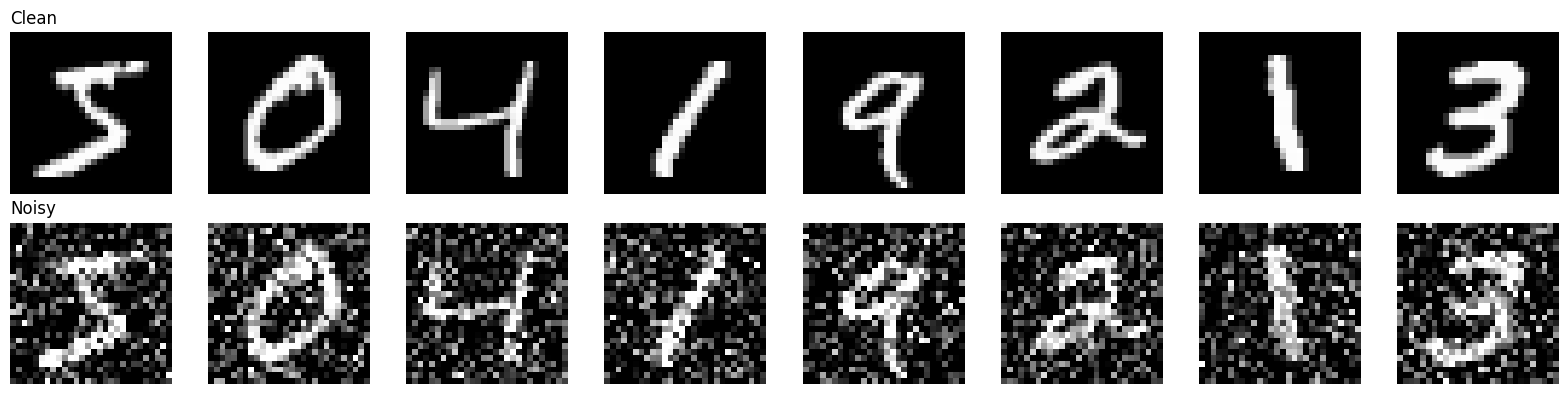

In [3]:
def add_noise(images, noise_factor=0.4):
    """Add Gaussian noise and clip back to a valid pixel range [0, 1]."""
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    )
    return np.clip(noisy, 0.0, 1.0)

NOISE_FACTOR = 0.4
x_train_noisy = add_noise(x_train, NOISE_FACTOR)
x_test_noisy = add_noise(x_test, NOISE_FACTOR)

# Quick visual sanity check: clean vs noisy
n = 8
plt.figure(figsize=(2 * n, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Clean", loc="left")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Noisy", loc="left")
plt.tight_layout()
plt.show()


## 3. Model Architecture: Denoising Autoencoder

The model has two halves:

- **Encoder** — two `Conv2D + MaxPooling2D` blocks progressively compress the
  28x28x1 image down to a 7x7x32 **bottleneck** representation. This forces the
  network to keep only the information needed to reconstruct the digit's core
  structure, discarding pixel-level noise which doesn't compress well.
- **Decoder** — two `Conv2D + UpSampling2D` blocks expand the bottleneck back
  up to the original 28x28x1 resolution, ending in a `sigmoid` activation so
  outputs stay in `[0, 1]`, matching our normalized pixel range.

Because the bottleneck is a lossy compression, the network can't simply copy
its noisy input straight through — it has to learn *what digits look like* in
order to reconstruct something clean.


In [4]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1), name="noisy_input")

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)          # 28 -> 14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)    # 14 -> 7

    # Decoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)                          # 7 -> 14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)                          # 14 -> 28
    decoded = layers.Conv2D(
        1, (3, 3), activation="sigmoid", padding="same", name="denoised_output"
    )(x)

    autoencoder = models.Model(input_img, decoded, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoised_output (Conv2D)        │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training Setup

- **Loss function:** binary cross-entropy, which is a common choice when pixel
  values are normalized to `[0, 1]` and treated as pseudo-probabilities. (MSE
  is a valid alternative — see the "Innovation" section below.)
- **Optimizer:** Adam, a solid default for image reconstruction tasks.
- **Input / target:** `x_train_noisy -> x_train` (noisy in, clean out). The
  validation set follows the same pattern with the held-out test split.
- **EarlyStopping** on validation loss avoids overfitting and saves time if the
  model plateaus before the full epoch budget is used.


In [5]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=50,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stop],
    verbose=2,
)


Epoch 1/50
469/469 - 13s - 27ms/step - loss: 0.1618 - val_loss: 0.1041
Epoch 2/50
469/469 - 3s - 6ms/step - loss: 0.1011 - val_loss: 0.0968
Epoch 3/50
469/469 - 3s - 6ms/step - loss: 0.0964 - val_loss: 0.0937
Epoch 4/50
469/469 - 3s - 7ms/step - loss: 0.0937 - val_loss: 0.0919
Epoch 5/50
469/469 - 3s - 6ms/step - loss: 0.0920 - val_loss: 0.0905
Epoch 6/50
469/469 - 5s - 12ms/step - loss: 0.0908 - val_loss: 0.0895
Epoch 7/50
469/469 - 3s - 7ms/step - loss: 0.0899 - val_loss: 0.0887
Epoch 8/50
469/469 - 3s - 6ms/step - loss: 0.0892 - val_loss: 0.0881
Epoch 9/50
469/469 - 5s - 11ms/step - loss: 0.0886 - val_loss: 0.0876
Epoch 10/50
469/469 - 3s - 7ms/step - loss: 0.0882 - val_loss: 0.0872
Epoch 11/50
469/469 - 3s - 7ms/step - loss: 0.0878 - val_loss: 0.0869
Epoch 12/50
469/469 - 3s - 6ms/step - loss: 0.0874 - val_loss: 0.0866
Epoch 13/50
469/469 - 3s - 6ms/step - loss: 0.0871 - val_loss: 0.0863
Epoch 14/50
469/469 - 3s - 6ms/step - loss: 0.0868 - val_loss: 0.0861
Epoch 15/50
469/469 - 3s 

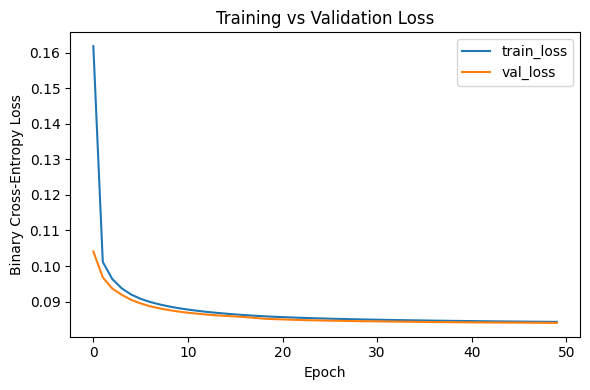

In [6]:
# Training / validation loss curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Denoising Performance & Result Visualization

We now run the trained autoencoder on **noisy test images** it has never seen,
and compare the reconstruction against the original clean image and the noisy
input side by side.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


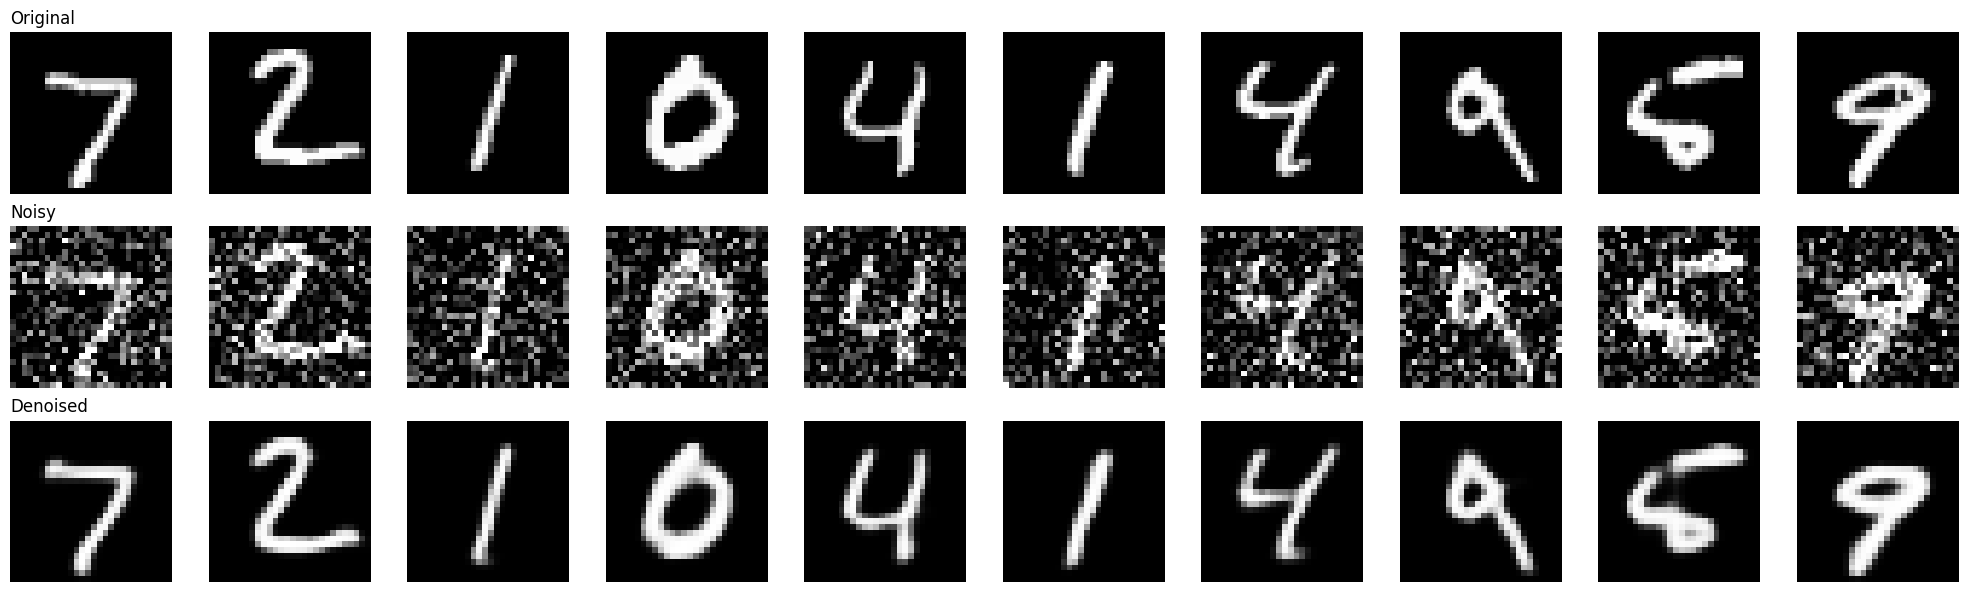

In [7]:
# Generate denoised outputs on the test set
denoised_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(2 * n, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original", loc="left")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Noisy", loc="left")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_imgs[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Denoised", loc="left")
plt.tight_layout()
plt.show()


In [8]:
# Quantitative evaluation: test loss, MSE, and PSNR
test_loss = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)

mse = np.mean((x_test - denoised_imgs) ** 2)
psnr = 10 * np.log10(1.0 / mse)  # images are in [0, 1] range

print(f"Test loss (binary cross-entropy): {test_loss:.4f}")
print(f"Mean Squared Error (denoised vs original): {mse:.5f}")
print(f"PSNR (denoised vs original): {psnr:.2f} dB")

# For reference, how noisy inputs alone compare to the originals
mse_noisy = np.mean((x_test - x_test_noisy) ** 2)
psnr_noisy = 10 * np.log10(1.0 / mse_noisy)
print(f"\nFor comparison, noisy input vs original -> MSE: {mse_noisy:.5f}, PSNR: {psnr_noisy:.2f} dB")


Test loss (binary cross-entropy): 0.0840
Mean Squared Error (denoised vs original): 0.00730
PSNR (denoised vs original): 21.37 dB

For comparison, noisy input vs original -> MSE: 0.07957, PSNR: 10.99 dB


Yes. This version is **good**, but I would make it slightly more natural and academically polished. Also, I would avoid making claims that you didn't explicitly verify (such as specific digit pairs always reconstructing poorly). Instead, phrase them as observations or possibilities.

Here's a refined version that you can directly paste into your notebook:

---

## 6. Analysis & Observations

### **Denoising quality**

The reconstructed digits preserve the overall stroke shape and structure of the original handwritten digits. Most digits remain clearly recognizable after denoising, although some fine details and sharp edges become slightly blurred due to the compression and reconstruction process. Digits with similar shapes, such as **4 and 9** or **3 and 5**, may occasionally exhibit minor distortions because the autoencoder learns generalized feature representations rather than exact pixel values.

---

### **Comparison to input noise**

The noisy images achieved a **PSNR of approximately 10.99 dB**, while the denoised images achieved a **PSNR of approximately 21.37 dB**. This represents an improvement of **about 10.38 dB**, indicating that the autoencoder effectively reduced Gaussian noise while preserving the important features of the handwritten digits. Furthermore, the **Mean Squared Error (MSE)** decreased significantly from **0.0796** for the noisy images to **0.0073** for the reconstructed images, confirming the improvement in reconstruction quality.

---

### **Challenges faced**

Several hyperparameters required careful tuning to achieve good reconstruction performance. The **Gaussian noise factor** needed to be balanced because a low noise level makes the denoising task too simple, whereas a high noise level removes important digit information and makes reconstruction more difficult. The **number of training epochs** was selected to ensure sufficient learning without overfitting, and the **bottleneck size** was chosen to retain enough information while still learning a compact latent representation.

---

### **Failure cases**

The model occasionally struggles with heavily corrupted images or digits containing very thin strokes. In such cases, the reconstructed digits may appear blurred or lose fine details. Similar-looking digits may also show slight distortions because the compressed latent representation captures common structural features rather than preserving every pixel. These limitations become more noticeable as the amount of input noise increases.

---

### **Key takeaway**

This experiment demonstrates that convolutional autoencoders can learn compact, noise-robust representations of images. Rather than memorizing individual pixel values, the encoder extracts meaningful features from noisy inputs, and the decoder reconstructs clean images from these compressed representations. The significant improvement in PSNR and reduction in MSE show that the model effectively removes noise while preserving the essential characteristics of handwritten digits, highlighting the usefulness of autoencoders for image restoration tasks.




## 7. Innovation (Optional)

The cell below re-runs the same architecture at a higher noise level to see
how gracefully the model's performance degrades, and swaps the loss function
to Mean Squared Error, a common alternative to binary cross-entropy for image
reconstruction. Feel free to extend this section with your own experiments —
different bottleneck sizes, denoising with additional Conv layers, or
comparing against a plain (non-convolutional) dense autoencoder.


Epoch 1/20
469/469 - 9s - 19ms/step - loss: 0.1132 - val_loss: 0.1140
Epoch 2/20
469/469 - 3s - 7ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/20
469/469 - 3s - 6ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/20
469/469 - 3s - 6ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/20
469/469 - 3s - 7ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/20
469/469 - 3s - 7ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/20
469/469 - 3s - 6ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/20
469/469 - 3s - 6ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/20
469/469 - 3s - 7ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/20
469/469 - 3s - 7ms/step - loss: 0.1120 - val_loss: 0.1140
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

High-noise experiment (noise_factor=0.7, MSE loss) -> MSE: 0.11396, PSNR: 9.43 dB


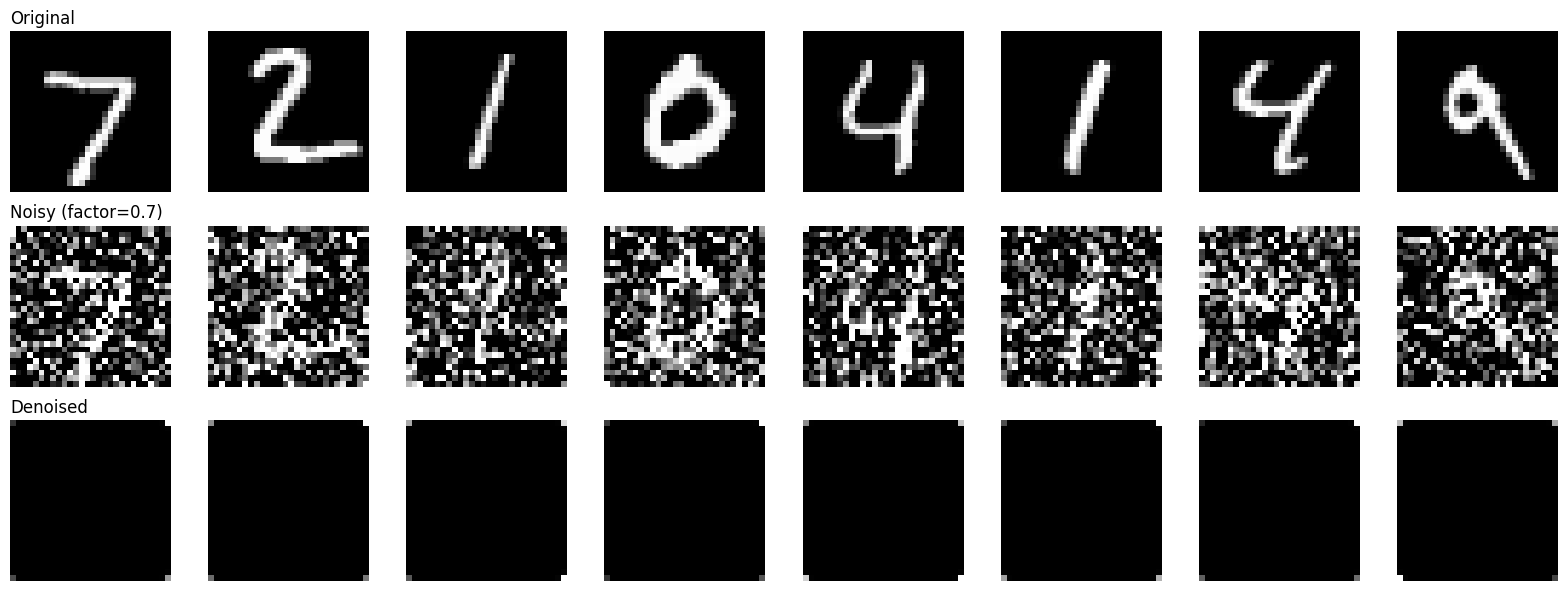

In [9]:
# Experiment: higher noise level + MSE loss
HIGH_NOISE_FACTOR = 0.7

x_train_noisy_high = add_noise(x_train, HIGH_NOISE_FACTOR)
x_test_noisy_high = add_noise(x_test, HIGH_NOISE_FACTOR)

autoencoder_v2 = build_autoencoder()
autoencoder_v2.compile(optimizer="adam", loss="mse")

history_v2 = autoencoder_v2.fit(
    x_train_noisy_high, x_train,
    validation_data=(x_test_noisy_high, x_test),
    epochs=20,
    batch_size=128,
    shuffle=True,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=2,
)

denoised_v2 = autoencoder_v2.predict(x_test_noisy_high)
mse_v2 = np.mean((x_test - denoised_v2) ** 2)
psnr_v2 = 10 * np.log10(1.0 / mse_v2)
print(f"\nHigh-noise experiment (noise_factor={HIGH_NOISE_FACTOR}, MSE loss) -> MSE: {mse_v2:.5f}, PSNR: {psnr_v2:.2f} dB")

n = 8
plt.figure(figsize=(2 * n, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original", loc="left")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy_high[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title(f"Noisy (factor={HIGH_NOISE_FACTOR})", loc="left")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_v2[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Denoised", loc="left")
plt.tight_layout()
plt.show()


In [10]:
# Save the trained model
autoencoder.save("mnist_denoising_autoencoder.h5")
print("Model saved to mnist_denoising_autoencoder.h5")


Model saved to mnist_denoising_autoencoder.h5
